# Grand Thera — USD/BRL · Neural SDE + Markov Regimes (Thera OS API)

**Decision-grade FX analytics for FP&A teams and quant desks.** All models run on the
**Thera OS A. If the API is unreachable, the notebook stops with
a clear error rather than silently approximating.

Three decisions from the daily USD/BRL series:

1. **30-day distributional forecast** of USD/BRL (Neural SDE, server-side).
2. **P(BRL depreciation > 5%)** — probability the dollar gains more than 5% vs. the real.
3. **Current regime**, **P(transition to bull/USD-strength)**, and **P(the series changes regime)**.

### Who this is for
- **FP&A / Treasury / CFO office** — size USD exposure on payables, revenue, and debt;
  feed *probability-weighted* rate scenarios into budgets, hedge ratios, and covenant
  headroom. `P(USD up > 5%)` ≈ "chance my unhedged dollar cost blows past budget in a month".
- **Quant desks** — regime-conditioned drift/vol, a transition matrix with dwell times and
  explicit regime-change probabilities, and a full terminal distribution with tail
  probabilities (`reached` vs `final`) for barrier/stop reasoning.

| Goal | Endpoint | Request → Response |
|---|---|---|
| Forecast + P(>5%) | `POST /api/v1/forecast/run` | `ForecastRunRequest` → `ForecastRunResponse` |
| Regime + P(→bull) + P(change) | `POST /api/v1/regime/analyze` | `RegimeAnalyzeRequest` → `RegimeAnalyzeResponse` |

**FX sign convention.** USD/BRL = reais per 1 USD. *Appreciation* = **dollar up / real down**.
`bull` = USD-strength regime (identified by the highest realized drift).
`P(>5%)` = P( USD/BRL₃₀ / spot − 1 > 0.05 ), horizon ≈ 21 trading days.

> **Note.** Only the USD/BRL **price series** is sourced externally (yfinance first, BCB SGS if needed).
> That series is the input sent to Thera OS. Every model output comes from the API.


In [ ]:
# === 0. Colab setup (run first; skip if local) ================================
import sys, subprocess, os
def _pip(*p): subprocess.run([sys.executable, "-m", "pip", "install", "-q", *p])
try:
    import yfinance, requests, scipy, matplotlib
except Exception:
    _pip("yfinance", "requests", "scipy", "matplotlib", "pandas", "numpy")

In [ ]:
# === 1. Configuration =========================================================
import os, math, json, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

# --- Thera OS API (required) ---
THERA_BASE_URL = "https://api.thera-os.com"

# --- Asset / window ---
YF_SYMBOL, BCB_SERIES_CODE = "USDBRL=X", 1
LOOKBACK_TRADING = 252

# --- Horizon / target ---
HORIZON_CALENDAR = 30
HORIZON_TRADING  = round(HORIZON_CALENDAR * 21 / 30)     # ~21 trading days = forecast steps
THRESHOLD        = 0.05

# --- Neural SDE (ForecastRunRequest) ---
FC_SIMULATIONS     = 4000
FC_DRIFT_SCALE     = 1.0
FC_DIFFUSION_SCALE = 1.0
FC_MEAN_REVERSION  = 0.18
FC_ROLLING_WINDOW  = 7

# --- Regime (RegimeAnalyzeRequest) ---
RG_N_REGIMES   = "auto"   # "auto" (BIC selection) or an integer (e.g. 3)
RG_WINDOW      = 20
RG_AUTO_METHOD = "bic"    # silhouette | aic | bic | icl

print(f"{YF_SYMBOL} | {LOOKBACK_TRADING} trading days | H={HORIZON_CALENDAR}d (~{HORIZON_TRADING} steps)"
      f" | target>+{THRESHOLD:.0%}")
print(f"API {THERA_BASE_URL}")


USDBRL=X | 252 trading days | H=30d (~21 steps) | target>+5%
API https://api.thera-os.com


In [ ]:
# === 2. Data: daily USD/BRL (last 252 trading days) — INPUT to the API ========
def _to_series(obj):
    """Coerce a yfinance Close (possibly a 1-col DataFrame / MultiIndex) to a 1-D Series."""
    if isinstance(obj, pd.DataFrame):
        obj = obj.iloc[:, 0]
    return pd.Series(np.asarray(obj).ravel(), index=obj.index, name="Close").astype(float)

def _logret(close):
    close = _to_series(close).dropna()
    return np.log(close).diff().dropna()

def load_usdbrl(n=LOOKBACK_TRADING):
    # 1) yfinance
    try:
        import yfinance as yf
        df = yf.download(YF_SYMBOL, period="500d", interval="1d",
                         progress=False, auto_adjust=False)
        close = _to_series(df["Close"]).dropna()
        if len(close) >= 30:
            close = close.tail(n)
            return close, _logret(close), "yfinance"
    except Exception as e:
        print("yfinance unavailable:", e)

    # 2) Banco Central do Brasil SGS 1: USD/BRL commercial selling rate, daily.
    # This is only a public market-data backup for the input series.
    try:
        import requests
        url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{BCB_SERIES_CODE}/dados/ultimos/{max(n + 40, 320)}?formato=json"
        r = requests.get(url, timeout=20)
        r.raise_for_status()
        rows = r.json()
        df = pd.DataFrame(rows)
        df["Date"] = pd.to_datetime(df["data"], dayfirst=True, errors="coerce")
        df["Close"] = pd.to_numeric(df["valor"], errors="coerce")
        close = df.dropna(subset=["Date", "Close"]).set_index("Date")["Close"].sort_index().tail(n)
        if len(close) >= 30:
            close.name = "Close"
            return close, _logret(close), "bcb_sgs_1"
    except Exception as e:
        print("BCB SGS unavailable:", e)

    raise RuntimeError("Could not load USD/BRL prices from yfinance or BCB SGS.")

CLOSE, LOGRET, DATA_SOURCE = load_usdbrl()
S0     = float(CLOSE.iloc[-1])
PRICES = [float(x) for x in CLOSE.values]
DATES  = [d.strftime("%Y-%m-%d") for d in CLOSE.index]
vol_annual = float(LOGRET.std()) * math.sqrt(252) * 100
print(f"source={DATA_SOURCE} | n={len(CLOSE)} | USD/BRL spot={S0:.4f} | "
      f"{CLOSE.index[0].date()} -> {CLOSE.index[-1].date()} | annualized vol~{vol_annual:.1f}%")


source=yfinance | n=252 | USD/BRL spot=5.0298 | 2025-06-13 -> 2026-06-03 | annualized vol~11.5%


In [ ]:
# === 3. Thera OS client + parsers (against the real openapi.json) =============
# (logic validated against schema-faithful mocks)
"""Thera OS client + parsers — written against the real openapi.json (v0.1.0).
Logic validated against schema-faithful mocks; identical code ships in the notebook.
"""
import os, json, math
import numpy as np
import requests

# ---- real paths ----
NEURAL_SDE_PATH = "/api/v1/forecast/run"     # ForecastRunRequest -> ForecastRunResponse
REGIME_PATH     = "/api/v1/regime/analyze"   # RegimeAnalyzeRequest -> RegimeAnalyzeResponse


class ApiUnavailable(Exception):
    pass


class TheraOSClient:
    def __init__(self, base_url, timeout=60):
        self.base_url = base_url.rstrip("/");  self.timeout = timeout
        self.health()

    def _post(self, path, payload):
        headers = {"Content-Type": "application/json"}
        try:
            r = requests.post(self.base_url + path, headers=headers, json=payload, timeout=self.timeout)
            if not r.ok:
                raise ApiUnavailable(f"{path}: HTTP {r.status_code} - {r.text[:800]}")
            return r.json()
        except ApiUnavailable:
            raise
        except Exception as e:
            raise ApiUnavailable(f"{path}: {e}")

    def health(self):
        try:
            print(requests.get(self.base_url + "/health", timeout=10).json())
            return
        except Exception as e:
            raise ApiUnavailable(f"/health: {e}")

    # --- Neural SDE ---
    def forecast_run(self, prices, steps, simulations, targets,
                     drift_scale=1.0, diffusion_scale=1.0, mean_reversion=0.18, rolling_window=7):
        return self._post(NEURAL_SDE_PATH, {
            "series": list(prices), "steps": int(steps), "simulations": int(simulations),
            "targets": list(targets), "drift_scale": drift_scale,
            "diffusion_scale": diffusion_scale, "mean_reversion": mean_reversion,
            "rolling_window": rolling_window})

    # --- Regime (Markov) ---
    def regime_analyze(self, prices, dates=None, n_regimes="auto", window=20,
                       auto_method="bic"):
        body = {"prices": list(prices), "window": int(window), "auto_method": auto_method}
        if dates is not None: body["dates"] = list(dates)
        body["n_regimes"] = "auto" if n_regimes == "auto" else int(n_regimes)
        return self._post(REGIME_PATH, body)


# ============================ PARSERS ============================
def parse_forecast_response(raw, S0, threshold):
    """ForecastRunResponse -> normalized dict (return space vs S0)."""
    tsum = raw["terminal_summary"]
    # targets: pick the 'above' closest to S0*(1+thr) and the 'below' closest to S0*(1-thr)
    tgt_above = S0 * (1 + threshold); tgt_below = S0 * (1 - threshold)
    above = below = None
    for tp in raw.get("target_probabilities", []):
        if tp["direction"] == "above" and (above is None or abs(tp["target"]-tgt_above) < abs(above["target"]-tgt_above)):
            above = tp
        if tp["direction"] == "below" and (below is None or abs(tp["target"]-tgt_below) < abs(below["target"]-tgt_below)):
            below = tp
    # terminal samples (for the histogram) from the simulation paths, if provided
    paths = raw.get("simulation_paths") or []
    term_ret = None
    if paths:
        term = np.array([p[-1] for p in paths if len(p)], float)
        term_ret = term / S0 - 1.0
    return {
        "provenance": "api",
        "median": tsum["p50"]/S0 - 1.0,
        "q05":    tsum["p05"]/S0 - 1.0,
        "q95":    tsum["p95"]/S0 - 1.0,
        "min":    tsum["min"]/S0 - 1.0,
        "max":    tsum["max"]/S0 - 1.0,
        "mean":   (float(term_ret.mean()) if term_ret is not None else tsum["p50"]/S0 - 1.0),
        "std":    (float(term_ret.std())  if term_ret is not None else None),
        "terminal_return": term_ret,
        "forecast_median": raw.get("forecast_median"),
        "forecast_lower":  raw.get("forecast_lower"),
        "forecast_upper":  raw.get("forecast_upper"),
        "terminal_distribution": raw.get("terminal_distribution"),
        "p_above_threshold":     (above["probability_final"]   if above else float("nan")),
        "p_above_reached":       (above["probability_reached"] if above else float("nan")),
        "p_above_overshoot":     (above["expected_overshoot"]  if above else float("nan")),
        "p_below_neg_threshold": (below["probability_final"]   if below else float("nan")),
        "target_above_level": tgt_above,
    }


def parse_regime_response(raw, logret):
    """RegimeAnalyzeResponse -> normalized dict. Identifies 'bull' by realized drift."""
    rows = raw["rows"]; T = np.asarray(raw["transition_matrix"], float)
    n = T.shape[0]
    viterbi = raw.get("viterbi_path") or [r["viterbi_label"] for r in rows]

    # label (str) -> transition-matrix index, via each row's cluster id
    idx_of_label = {}
    for r in rows:
        idx_of_label.setdefault(r["viterbi_label"], int(r.get("cluster", len(idx_of_label))))
    # ensure all indices 0..n-1 are covered;
    if set(idx_of_label.values()) != set(range(n)):
        idx_of_label = {}
        for lab in viterbi:
            if lab not in idx_of_label: idx_of_label[lab] = len(idx_of_label)
    label_of_idx = {v: k for k, v in idx_of_label.items()}

    # Prefer backend regime summaries for drift. They are already aligned to the
    # rolling-window rows returned by the API; viterbi_path can be shorter than LOGRET.
    summary = raw.get("summary") or {}
    drift = {}
    for lab in idx_of_label:
        val = (summary.get(lab) or {}).get("avg_mean_return")
        if val is not None:
            drift[lab] = float(val)
    if set(drift) != set(idx_of_label):
        grouped = {}
        for r in rows:
            lab = r.get("viterbi_label") or r.get("label")
            feat = r.get("features") or {}
            if lab in idx_of_label and "mean_return" in feat:
                grouped.setdefault(lab, []).append(float(feat["mean_return"]))
        for lab in idx_of_label:
            vals = grouped.get(lab, [])
            drift.setdefault(lab, float(np.mean(vals)) if vals else 0.0)
    bull_label = max(drift, key=drift.get); bear_label = min(drift, key=drift.get)
    bull_idx = idx_of_label[bull_label]

    cur = rows[-1]
    cur_label = cur["viterbi_label"]; cur_idx = idx_of_label[cur_label]
    fp = cur.get("filtered_probabilities") or {cur_label: 1.0}
    pvec = np.zeros(n)
    for lab, pr in fp.items():
        if lab in idx_of_label: pvec[idx_of_label[lab]] = pr
    if pvec.sum() == 0: pvec[cur_idx] = 1.0
    pvec = pvec / pvec.sum()

    return {
        "provenance": "api",
        "n_regimes": int(raw.get("n_regimes", n)),
        "transition_matrix": T,
        "labels": label_of_idx,
        "regime_drift": drift,
        "bull_label": bull_label, "bear_label": bear_label, "bull_index": bull_idx,
        "current_label": cur_label, "current_index": cur_idx,
        "current_filtered": fp,
        "current_pvec": pvec,
        "viterbi_path": list(viterbi),
        "uncertainty": cur.get("uncertainty"),
        "selection_scores": raw.get("selection_scores"),
    }


def regime_horizon_probs(regime, horizon):
    """P(bull at horizon) and P(->bull next step) from the normalized regime dict."""
    T = regime["transition_matrix"]; bull = regime["bull_index"]
    pvec = regime["current_pvec"]; cur = regime["current_index"]
    Pn = np.linalg.matrix_power(T, horizon)
    p_bull_h = float((pvec @ Pn)[bull])
    p_to_bull_next = float("nan") if cur == bull else float(T[cur, bull])
    dwell = {regime["labels"][i]: (float(1/(1-T[i, i])) if T[i, i] < 1 else float("inf"))
             for i in range(T.shape[0])}
    return p_bull_h, p_to_bull_next, dwell


def regime_change_probs(regime, horizon):
    """Probability the series LEAVES the current regime — next step and within the horizon."""
    T = regime["transition_matrix"]; cur = regime["current_index"]; lab = regime["labels"]
    Pn = np.linalg.matrix_power(T, horizon)
    p_stay_next   = float(T[cur, cur]);      p_change_next = 1.0 - p_stay_next
    p_stay_h      = float(Pn[cur, cur]);     p_change_h    = 1.0 - p_stay_h
    to_each_next  = {lab[j]: float(T[cur, j])  for j in range(T.shape[0]) if j != cur}
    to_each_h     = {lab[j]: float(Pn[cur, j]) for j in range(T.shape[0]) if j != cur}
    return {"current": lab[cur],
            "p_stay_next": p_stay_next, "p_change_next": p_change_next,
            "p_stay_h": p_stay_h, "p_change_h": p_change_h,
            "to_each_next": to_each_next, "to_each_h": to_each_h}


In [ ]:
# === 4. Orchestration — 100% Thera OS ============================
THERA = TheraOSClient(THERA_BASE_URL)
# --- Regime ---
try:
    raw_regime = THERA.regime_analyze(PRICES, DATES, RG_N_REGIMES, RG_WINDOW, RG_AUTO_METHOD)
except ApiUnavailable as e:
    raise RuntimeError(f"Thera OS regime call failed: {e}.") from e
REGIME = parse_regime_response(raw_regime, LOGRET.values)
P_BULL_H, P_TO_BULL_NEXT, DWELL = regime_horizon_probs(REGIME, HORIZON_TRADING)
CHANGE = regime_change_probs(REGIME, HORIZON_TRADING)
print("Regime  : Thera OS /api/v1/regime/analyze  ->", REGIME["current_label"])

# --- Neural SDE forecast ---
targets = [round(S0*(1+THRESHOLD), 6), round(S0*(1-THRESHOLD), 6)]   # price levels
try:
    raw_fc = THERA.forecast_run(PRICES, HORIZON_TRADING, FC_SIMULATIONS, targets,
                                FC_DRIFT_SCALE, FC_DIFFUSION_SCALE, FC_MEAN_REVERSION, FC_ROLLING_WINDOW)
except ApiUnavailable as e:
    raise RuntimeError(f"Thera OS forecast call failed: {e}.") from e
FORECAST = parse_forecast_response(raw_fc, S0, THRESHOLD)
print("Forecast: Thera OS /api/v1/forecast/run  -> P(>+5%) final =",
      f"{FORECAST['p_above_threshold']*100:.1f}%")


{'status': 'ok', 'service': 'Thera OS Public API', 'version': '0.1.0'}
Regime  : Thera OS /api/v1/regime/analyze  -> regime_4
Forecast: Thera OS /api/v1/forecast/run  -> P(>+5%) final = 1.8%


In [ ]:
# === 5. Report + dashboard functions (validated standalone) ==================
"""Report + dashboard for the Thera OS USD/BRL notebook.
Tested standalone with schema-faithful mocks; the same source is embedded in the notebook.
"""
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch, Rectangle
from scipy.stats import norm


def regime_palette(regime):
    bull, bear = regime["bull_label"], regime["bear_label"]
    extra = ["#a0aec0", "#4299e1", "#ed8936", "#9f7aea", "#38b2ac"]
    others = [l for i, l in sorted(regime["labels"].items()) if l not in (bull, bear)]
    cmap = {bull: "#38a169", bear: "#e53e3e"}
    for j, l in enumerate(others):
        cmap[l] = extra[j % len(extra)]
    return cmap


def _runs(labels):
    runs, s = [], 0
    for i in range(1, len(labels)):
        if labels[i] != labels[i-1]:
            runs.append((s, i-1, labels[i-1])); s = i
    runs.append((s, len(labels)-1, labels[-1]))
    return runs


def empirical_horizon_returns(logret, horizon):
    """Overlapping horizon-day simple returns bootstrapped from the WHOLE series."""
    lr = np.asarray(logret, float)
    if len(lr) <= horizon:
        return np.array([])
    return np.array([math.expm1(lr[i:i+horizon].sum()) for i in range(len(lr)-horizon+1)])


def print_report(S0, HC, HT, THR, DATA_SOURCE, REGIME, FORECAST, CHANGE,
                 P_BULL_H, P_TO_BULL_NEXT, DWELL, LOGRET):
    S30 = lambda r: S0*(1+r)
    p5f, p5r = FORECAST["p_above_threshold"], FORECAST["p_above_reached"]
    L = []
    L.append("="*72)
    L.append(f"  USD/BRL · {HC}d FORECAST (~{HT} steps) · Grand Thera (Thera OS API)")
    L.append(f"  data:{DATA_SOURCE} | forecast:{FORECAST['provenance']} | regime:{REGIME['provenance']}")
    L.append("="*72)
    L.append(f"  Spot ......................... {S0:.4f}")
    L.append(f"  Median return (p50) .......... {FORECAST['median']*100:+.2f}%"
             + (f"   (mean {FORECAST['mean']*100:+.2f}%)" if FORECAST.get('mean') is not None else ""))
    L.append(f"  90% band (p05-p95) ........... {FORECAST['q05']*100:+.2f}% to {FORECAST['q95']*100:+.2f}%")
    L.append(f"  Projected price (p50) ........ {S30(FORECAST['median']):.4f}"
             f"   [{S30(FORECAST['q05']):.4f} - {S30(FORECAST['q95']):.4f}]")
    L.append("-"*72)
    L.append(f"  > P(USD appreciates >+5%, final) ... {p5f*100:5.1f}%")
    L.append(f"    P(touches +5% at any point) ...... {p5r*100:5.1f}%")
    ov = FORECAST.get('p_above_overshoot')
    if ov is not None and ov == ov:
        L.append(f"    expected overshoot beyond target . {ov*100:.2f}%")
    L.append(f"    P(USD falls <-5%, final) ......... {FORECAST['p_below_neg_threshold']*100:5.1f}%")
    L.append("-"*72)
    cl = REGIME['current_label']
    cls = ('BULL' if cl == REGIME['bull_label'] else 'BEAR' if cl == REGIME['bear_label'] else 'NEUTRAL')
    L.append(f"  Current regime ............... {cl}  (class: {cls})")
    L.append(f"    'bull' regime (USD strong) = {REGIME['bull_label']}  |  n_regimes={REGIME['n_regimes']}")
    L.append(f"    filtered probs (today) ... " +
             " | ".join(f"{k}:{v*100:.0f}%" for k, v in REGIME['current_filtered'].items()))
    L.append(f"  > P(transition to BULL in {HT} steps) . {P_BULL_H*100:5.1f}%")
    L.append(f"    P(->bull next step) .............. "
             + ("already bull" if P_TO_BULL_NEXT != P_TO_BULL_NEXT else f"{P_TO_BULL_NEXT*100:4.1f}%"))
    L.append(f"    expected dwell / regime .......... " +
             " | ".join(f"{k}:{'>252' if v==float('inf') else f'{v:.0f}'}d" for k, v in DWELL.items()))
    L.append("-"*72)
    L.append(f"  REGIME-CHANGE PROBABILITY (leaving '{CHANGE['current']}')")
    L.append(f"    next step:  stay {CHANGE['p_stay_next']*100:4.1f}%  |  change {CHANGE['p_change_next']*100:4.1f}%")
    L.append(f"    in {HT} steps: stay {CHANGE['p_stay_h']*100:4.1f}%  |  change {CHANGE['p_change_h']*100:4.1f}%")
    L.append(f"    destination if it changes (in {HT} steps): " +
             " | ".join(f"{k}:{v*100:.0f}%" for k, v in CHANGE['to_each_h'].items()))
    L.append("="*72)
    mdr = float(np.mean(LOGRET))*HT; mvol = float(np.std(LOGRET))*math.sqrt(HT)
    L.append(f"  [sanity] i.i.d. lognormal P(>+5%) = "
             f"{(1-norm.cdf((math.log(1+THR)-mdr)/mvol))*100:.1f}%")
    print("\n".join(L))


def _terminal_samples(FORECAST, S0):
    """Return (terminal_prices, terminal_returns) from paths if present, else from bins."""
    if FORECAST.get("terminal_return") is not None:
        ret = np.asarray(FORECAST["terminal_return"], float)
        return S0*(1+ret), ret
    td = FORECAST.get("terminal_distribution")
    if td and td.get("bins"):
        mids = np.array([b["mid"] for b in td["bins"]], float)
        cnt = np.array([b["count"] for b in td["bins"]], float)
        reps = np.repeat(mids, cnt.astype(int))
        return reps, reps/S0 - 1.0
    return None, None


def plot_dashboard(CLOSE, LOGRET, S0, HC, HT, THR, REGIME, FORECAST, CHANGE, P_BULL_H,
                   savepath=None):
    import pandas as pd
    cmap = regime_palette(REGIME)
    n_reg = REGIME["transition_matrix"].shape[0] if hasattr(REGIME["transition_matrix"], "shape") \
        else len(REGIME["transition_matrix"])
    labels = [REGIME["labels"][i] for i in range(n_reg)]
    T = np.asarray(REGIME["transition_matrix"], float)

    # ---------- FIGURE A: transition matrix + regime-change bars ----------
    figA, ax = plt.subplots(1, 2, figsize=(13, 4.4))
    im = ax[0].imshow(T, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax[0].set_xticks(range(n_reg)); ax[0].set_xticklabels(labels, rotation=20, ha="right")
    ax[0].set_yticks(range(n_reg)); ax[0].set_yticklabels(labels)
    ax[0].set_xlabel("to regime"); ax[0].set_ylabel("from regime")
    ax[0].set_title("Transition probability matrix", fontsize=11)
    for i in range(n_reg):
        for j in range(n_reg):
            ax[0].text(j, i, f"{T[i,j]:.2f}", ha="center", va="center",
                       color="white" if T[i, j] > 0.5 else "#1a202c", fontsize=9)
    cur_i = REGIME["current_index"]
    ax[0].add_patch(Rectangle((-0.5, cur_i-0.5), n_reg, 1, fill=False, edgecolor="#dd6b20", lw=2.2))
    figA.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)

    # change destinations within horizon, from current regime
    dest = [("stay", CHANGE["p_stay_h"], cmap[CHANGE["current"]])]
    for k, v in CHANGE["to_each_h"].items():
        dest.append((f"-> {k}", v, cmap.get(k, "#a0aec0")))
    ax[1].bar([d[0] for d in dest], [d[1]*100 for d in dest], color=[d[2] for d in dest])
    for i, d in enumerate(dest):
        ax[1].text(i, d[1]*100+1.5, f"{d[1]*100:.0f}%", ha="center", fontsize=9)
    ax[1].set_ylim(0, 100); ax[1].set_ylabel("probability (%)")
    ax[1].set_title(f"From '{CHANGE['current']}' in {HT} steps  |  "
                    f"P(change)={CHANGE['p_change_h']*100:.0f}%  "
                    f"(next step {CHANGE['p_change_next']*100:.0f}%)", fontsize=10.5)
    figA.tight_layout()

    # ---------- FIGURE B: regime-shaded series + projection cone + marginal dist ----------
    figB = plt.figure(figsize=(13, 4.8))
    gs = figB.add_gridspec(1, 2, width_ratios=[6, 1], wspace=0.02)
    axS = figB.add_subplot(gs[0, 0]); axM = figB.add_subplot(gs[0, 1], sharey=axS)

    vit = REGIME.get("viterbi_path") or [REGIME["current_label"]]*len(CLOSE)
    m = min(len(vit), len(CLOSE)); vit = list(vit)[-m:]
    idx = CLOSE.index[-m:]; px = CLOSE.values[-m:]
    for a, b, lab in _runs(vit):
        axS.axvspan(idx[a], idx[b], color=cmap.get(lab, "#a0aec0"), alpha=0.13, lw=0)
    axS.plot(idx, px, color="#1a202c", lw=1.2)
    # projection cone
    fut = pd.bdate_range(start=CLOSE.index[-1], periods=HT+1)[1:]
    fm, fl, fu = FORECAST.get("forecast_median"), FORECAST.get("forecast_lower"), FORECAST.get("forecast_upper")
    if fm and fl and fu and len(fm) == len(fut):
        axS.plot(fut, fm, color="#2b6cb0", lw=1.6, ls="--")
        axS.fill_between(fut, fl, fu, color="#2b6cb0", alpha=0.18)
    else:
        axS.plot([CLOSE.index[-1], fut[-1]], [S0, S0*(1+FORECAST["median"])], color="#2b6cb0", lw=1.6, ls="--")
        axS.fill_between([CLOSE.index[-1], fut[-1]], [S0, S0*(1+FORECAST["q05"])],
                         [S0, S0*(1+FORECAST["q95"])], color="#2b6cb0", alpha=0.18)
    axS.axhline(S0*(1+THR), color="#e53e3e", lw=1, ls=":")
    axS.set_title("USD/BRL — series highlighted by regime + 30d forecast distribution", fontsize=11)
    legend = [Patch(facecolor=cmap[l], alpha=0.4, label=l) for l in labels]
    legend += [plt.Line2D([0], [0], color="#2b6cb0", ls="--", label="projected median"),
               plt.Line2D([0], [0], color="#e53e3e", ls=":", label="+5%")]
    axS.legend(handles=legend, fontsize=8, loc="upper left", ncol=2)

    term_px, term_ret = _terminal_samples(FORECAST, S0)
    if term_px is not None:
        axM.hist(term_px, bins=80, orientation="horizontal", color="#2b6cb0", alpha=0.85, density=True)
        axM.axhline(S0*(1+THR), color="#e53e3e", lw=1, ls=":")
        axM.axhline(S0*(1+FORECAST["median"]), color="#1a202c", lw=1.2)
    axM.set_title("terminal\n(30d)", fontsize=9)
    axM.tick_params(labelleft=False); axM.set_xticks([])
    for sp in ("top", "right", "bottom"): axM.spines[sp].set_visible(False)
    figB.subplots_adjust(left=0.055, right=0.975, top=0.9, bottom=0.12)

    # ---------- FIGURE C: 30d return distribution — model vs whole-series empirical ----------
    figC, axc = plt.subplots(figsize=(13, 4.2))
    emp = empirical_horizon_returns(LOGRET, HT)
    if term_ret is not None:
        axc.hist(term_ret*100, bins=100, density=True, color="#2b6cb0", alpha=0.6,
                 label=f"Thera OS model ({HT}d)")
    if len(emp):
        axc.hist(emp*100, bins=60, density=True, color="#dd6b20", alpha=0.45,
                 label=f"empirical, whole series ({HT}d rolling)")
    axc.axvline(THR*100, color="#e53e3e", lw=2, ls="--")
    pm = FORECAST["p_above_threshold"]; pe = float(np.mean(emp > THR)) if len(emp) else float("nan")
    axc.set_title(f"USD/BRL — {HC}d return distribution   |   "
                  f"P(>+5%): model {pm*100:.1f}%  vs  empirical {pe*100:.1f}%", fontsize=11)
    axc.set_xlabel("return (%)"); axc.set_ylabel("density")
    axc.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0)); axc.legend(fontsize=9)
    figC.tight_layout()

    if savepath:
        figA.savefig(savepath+"_A.png", dpi=80); figB.savefig(savepath+"_B.png", dpi=80)
        figC.savefig(savepath+"_C.png", dpi=80)
    return figA, figB, figC


In [ ]:
# === 6. Quant report ==========================================================
print_report(S0, HORIZON_CALENDAR, HORIZON_TRADING, THRESHOLD, DATA_SOURCE,
             REGIME, FORECAST, CHANGE, P_BULL_H, P_TO_BULL_NEXT, DWELL, LOGRET.values)


  USD/BRL · 30d FORECAST (~21 steps) · Grand Thera (Thera OS API)
  data:yfinance | forecast:api | regime:api
  Spot ......................... 5.0298
  Median return (p50) .......... -0.31%   (mean -0.34%)
  90% band (p05-p95) ........... -4.58% to +3.84%
  Projected price (p50) ........ 5.0141   [4.7996 - 5.2229]
------------------------------------------------------------------------
  > P(USD appreciates >+5%, final) ...   1.8%
    P(touches +5% at any point) ......   3.6%
    expected overshoot beyond target . 0.11%
    P(USD falls <-5%, final) .........   3.5%
------------------------------------------------------------------------
  Current regime ............... regime_4  (class: NEUTRAL)
    'bull' regime (USD strong) = regime_5  |  n_regimes=5
    filtered probs (today) ... regime_1:10% | regime_2:28% | regime_3:14% | regime_4:41% | regime_5:8%
  > P(transition to BULL in 21 steps) .  21.9%
    P(->bull next step) ..............  1.9%
    expected dwell / regime .......... reg

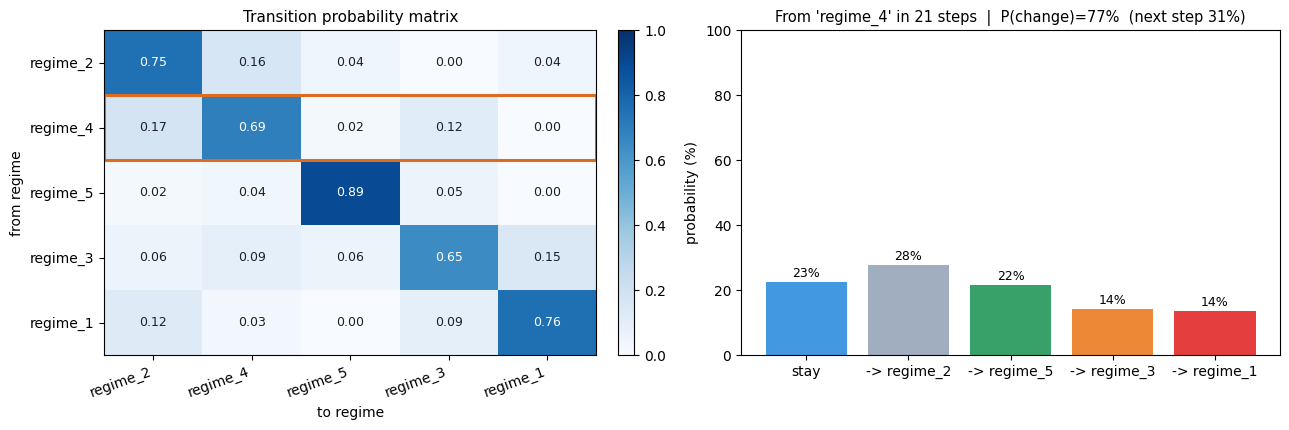

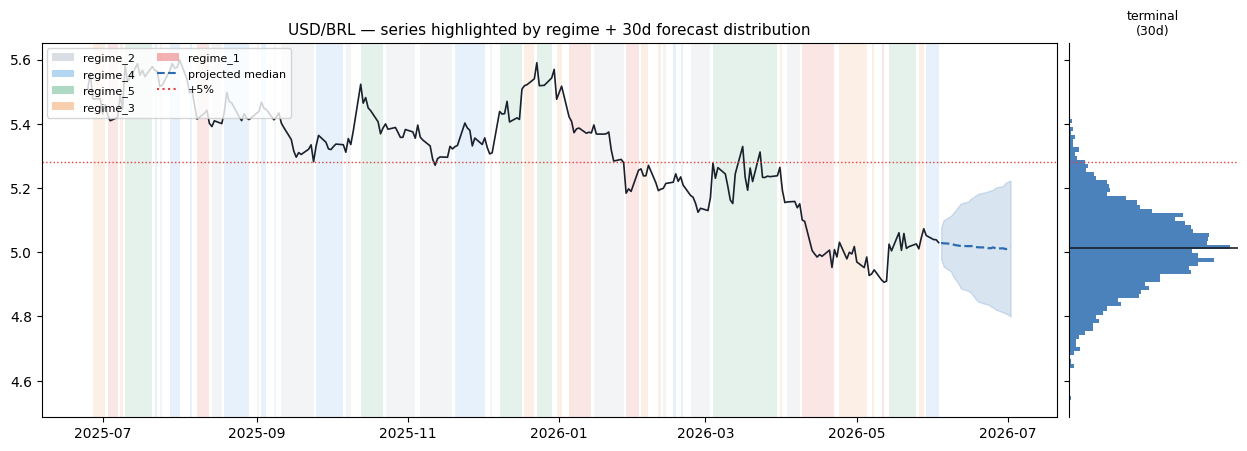

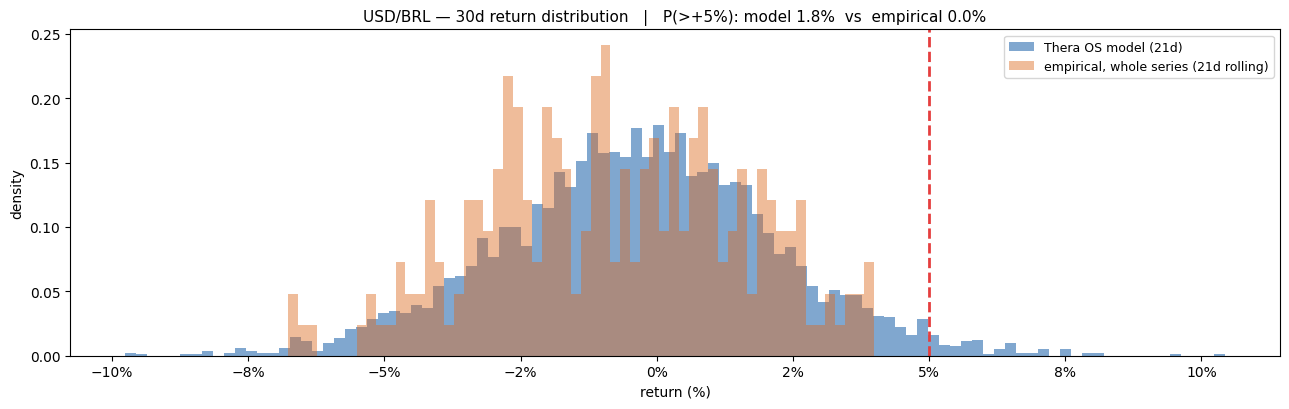

In [ ]:
# === 7. Dashboard =============================================================
# Fig A: transition matrix + regime-change probabilities
# Fig B: USD/BRL highlighted by regime + 30d forecast distribution (marginal on the price axis)
# Fig C: 30d return distribution — Thera OS model vs whole-series empirical
import matplotlib.pyplot as plt
plot_dashboard(CLOSE, LOGRET.values, S0, HORIZON_CALENDAR, HORIZON_TRADING, THRESHOLD,
               REGIME, FORECAST, CHANGE, P_BULL_H)
plt.show()


## Reading the output (caveats)

- **100% Thera OS.** Forecast and regime analysis are computed by the Grand Thera API.
- **Regime-change probability** is explicit: `P(stay)` vs `P(change)` next step and over the
  horizon (`regime_change_probs`), with the destination breakdown and the full transition
  matrix in Fig A.
- **Headline = `P(USD appreciates >5%, final)`** (`probability_final` of the `above` target).
  `probability_reached` (touches +5% intramonth) is always ≥ the final figure — for
  barriers/stops, not terminal direction.
- **Distribution over the whole series.** Fig B attaches the model's terminal distribution as
  a marginal on the price axis; Fig C compares the model's 30d distribution against the
  empirical distribution of overlapping 21-day returns across the full 252-day series.
- **`bull` is identified by realized drift**, not by an API label (`viterbi_label` may be
  `Regime k`); label↔matrix index is mapped via `cluster`.
- **FP&A use.** Budget at the p50 rate, stress at p95, and size hedges so unhedged exposure
  above budget carries acceptably low `P(>5%)`. The Fig B cone is the scenario fan.
- **+5% in ~21 trading days is a tail** (~1.2–1.5σ at USD/BRL monthly vol); compare the API
  figure with the i.i.d. lognormal sanity print and the empirical distribution in Fig C.

### API contract checked
`targets` are passed as **price levels** (`S0*1.05`), matching `ForecastRunRequest.targets` and the price-space `terminal_summary` / `forecast_*` response fields in the public OpenAPI.

### Other Thera OS endpoints (not used here)
`/api/v1/regime/upload`, `/api/v1/forecast/upload` (CSV/XLSX upload), and the
`/api/v1/symbolic/*` family (symbolic regression: `fit`, `predict`, `scenario`).
